<a href="https://colab.research.google.com/github/AdiRatnam/Hands_on_Pytorch/blob/main/dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils.data import Subset

In [3]:
mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.25, 0.25, 0.25])
data_transforms = {
    'train': transforms.Compose([
       transforms.Resize(256),
       transforms.CenterCrop(224),  # replace these 2 to make train val identical
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

In [1]:
import os

print(os.listdir('/content'))

['.config', 'PlantVillage_Potato.zip', 'sample_data']


In [4]:
import zipfile

with zipfile.ZipFile('/content/PlantVillage_Potato.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [5]:
import os

print(os.listdir('/content'))

['.config', 'Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight', 'PlantVillage_Potato.zip', 'sample_data']


In [6]:
import os
import shutil
import random

source_classes = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]

base_dir = "/content/PlantVillage_Potato"

for split in ["train", "val"]:
    for cls in source_classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

for cls in source_classes:

    source_folder = f"/content/{cls}"

    images = os.listdir(source_folder)

    random.shuffle(images)

    split_index = int(0.8 * len(images))

    train_images = images[:split_index]
    val_images = images[split_index:]

    for img in train_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(base_dir, "train", cls, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(base_dir, "val", cls, img)
        )

print("Done")

Done


In [7]:
print(os.listdir('/content/PlantVillage_Potato'))

['train', 'val']


In [8]:
print(os.listdir('/content/PlantVillage_Potato/train'))

['Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight']


In [9]:
data_dir = '/content/PlantVillage_Potato'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

image_datasets['train'] = Subset(
    image_datasets['train'],
    torch.randperm(len(image_datasets['train']))[:25])  # Reduce training set to 30 random data


dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}

dataset_sizes = {
    'train': 30,
    'val': len(image_datasets['val'])}  # Change dataset size

class_names = image_datasets['val'].classes #change to val classes cuz it still image folder but train is changed

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(class_names)
print(dataset_sizes)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
{'train': 30, 'val': 431}


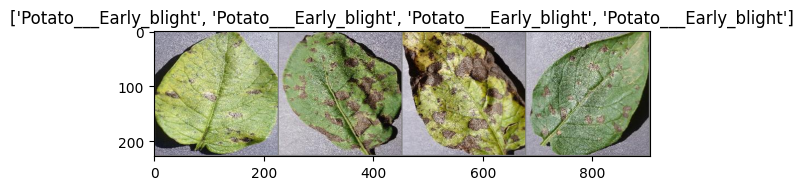

In [10]:
def imshow(inp, title):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.title(title)
    plt.show()

    # Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [11]:
train_losses = []
val_losses = []
def train_model(model, criterion, optimizer, scheduler, num_epochs=30):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0) # mul Because later we want the average loss over the whole dataset.
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step() #Multiply learning rate by 0.1 every 7 epoch, shown later

            epoch_loss = running_loss / dataset_sizes[phase]
            if phase == 'train':
              train_losses.append(epoch_loss)
            else:
              val_losses.append(epoch_loss)

            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model



In [14]:
#### Finetuning the convnet ####
# Load a pretrained model and reset final fully connected layer.

model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).

#model.fc = nn.Linear(num_ftrs, len(class_names)) -> without droupout

# by adding droupout
model.fc = nn.Sequential(nn.Dropout(0.5),nn.Linear(num_ftrs,len(class_names)))

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized Entire ResNet VVI LINE
optimizer = optim.SGD(model.parameters(), lr=0.001)

# StepLR Decays the learning rate of each parameter group by gamma every step_size epochs
# Decay LR by a factor of 0.1 every 7 epochs
# Learning rate scheduling should be applied after optimizer’s update
# e.g., you should write your code this way:
# for epoch in range(100):
#     train(...)
#     validate(...)
#     scheduler.step()

step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model = train_model(model, criterion, optimizer, step_lr_scheduler, num_epochs=30)


Epoch 0/29
----------
train Loss: 0.9031 Acc: 0.4333
val Loss: 1.0523 Acc: 0.4455

Epoch 1/29
----------
train Loss: 0.7040 Acc: 0.5333
val Loss: 0.9803 Acc: 0.4455

Epoch 2/29
----------
train Loss: 0.6735 Acc: 0.5000
val Loss: 1.0791 Acc: 0.4617

Epoch 3/29
----------
train Loss: 0.4866 Acc: 0.6000
val Loss: 0.9549 Acc: 0.4664

Epoch 4/29
----------
train Loss: 0.4838 Acc: 0.6333
val Loss: 0.9452 Acc: 0.4826

Epoch 5/29
----------
train Loss: 0.3529 Acc: 0.6333
val Loss: 1.0735 Acc: 0.4664

Epoch 6/29
----------
train Loss: 0.3143 Acc: 0.7667
val Loss: 0.9380 Acc: 0.4988

Epoch 7/29
----------
train Loss: 0.3280 Acc: 0.7000
val Loss: 0.9456 Acc: 0.4988

Epoch 8/29
----------
train Loss: 0.3823 Acc: 0.6000
val Loss: 0.9189 Acc: 0.5128

Epoch 9/29
----------
train Loss: 0.4381 Acc: 0.6000
val Loss: 0.9302 Acc: 0.5035

Epoch 10/29
----------
train Loss: 0.3420 Acc: 0.7000
val Loss: 0.9184 Acc: 0.5220

Epoch 11/29
----------
train Loss: 0.3240 Acc: 0.6667
val Loss: 0.9212 Acc: 0.5081

Ep

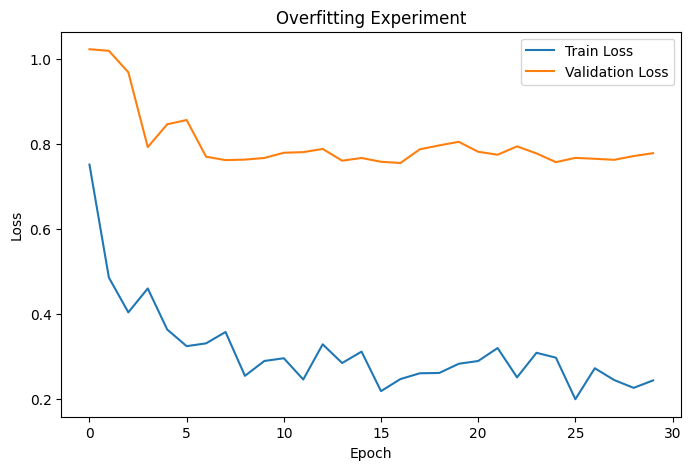

In [13]:
#plot without droupout
plt.figure(figsize=(8,5))

plt.plot(train_losses,
         label='Train Loss')

plt.plot(val_losses,
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Experiment')

plt.legend()

plt.show()

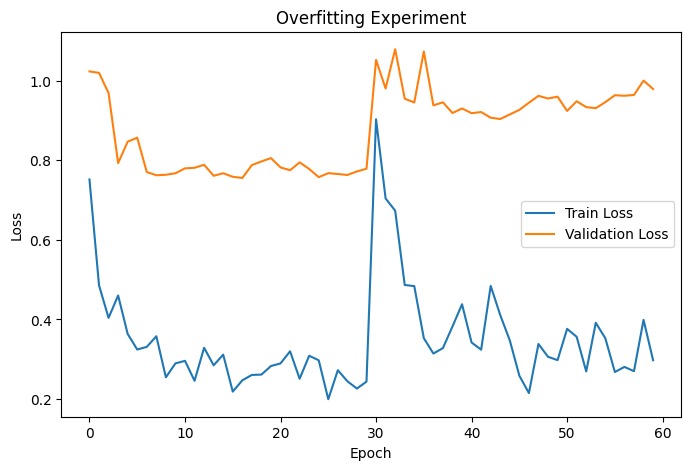

In [15]:
#plot with droupout
plt.figure(figsize=(8,5))

plt.plot(train_losses,
         label='Train Loss')

plt.plot(val_losses,
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Overfitting Experiment')

plt.legend()

plt.show()

#does droupout always improve performance?
No.

Dropout is a regularization technique.

On small datasets or already simple tasks,
it can reduce performance by making learning harder. here we have less image with dropout 0.5

 Observations

1. Overfitting was observed when training on only 25 images for many epochs. Training loss continued to decrease while validation loss stopped improving after the initial epochs.

2. Removing data augmentation made memorization easier and exposed overfitting more clearly.

3. Adding Dropout(0.5) before the final layer reduced performance significantly. Validation accuracy dropped from 70.07% to 52.67%.

4. The dropout rate was too aggressive for such a small dataset. Instead of reducing overfitting effectively, it made learning harder and led to underfitting.

5. model.train() enables dropout and training behavior, while model.eval() disables dropout and is required for reliable validation metrics.

Key takeaway: Regularization techniques such as dropout are not guaranteed to improve performance. Their effectiveness depends on the dataset size, model capacity, and task.
